Đang tải dữ liệu từ UCI Machine Learning Repository... Vui lòng đợi trong giây lát.
Tải dữ liệu thành công! Kích thước tập dữ liệu: (30000, 25)
---------------------------------------------


/tmp/ipykernel_7223/4250045870.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], x='Is_Default', data=df, palette='Set2')
/tmp/ipykernel_7223/4250045870.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], x='Is_Default', y='LIMIT_BAL', data=df, palette='Pastel1', showfliers=False)


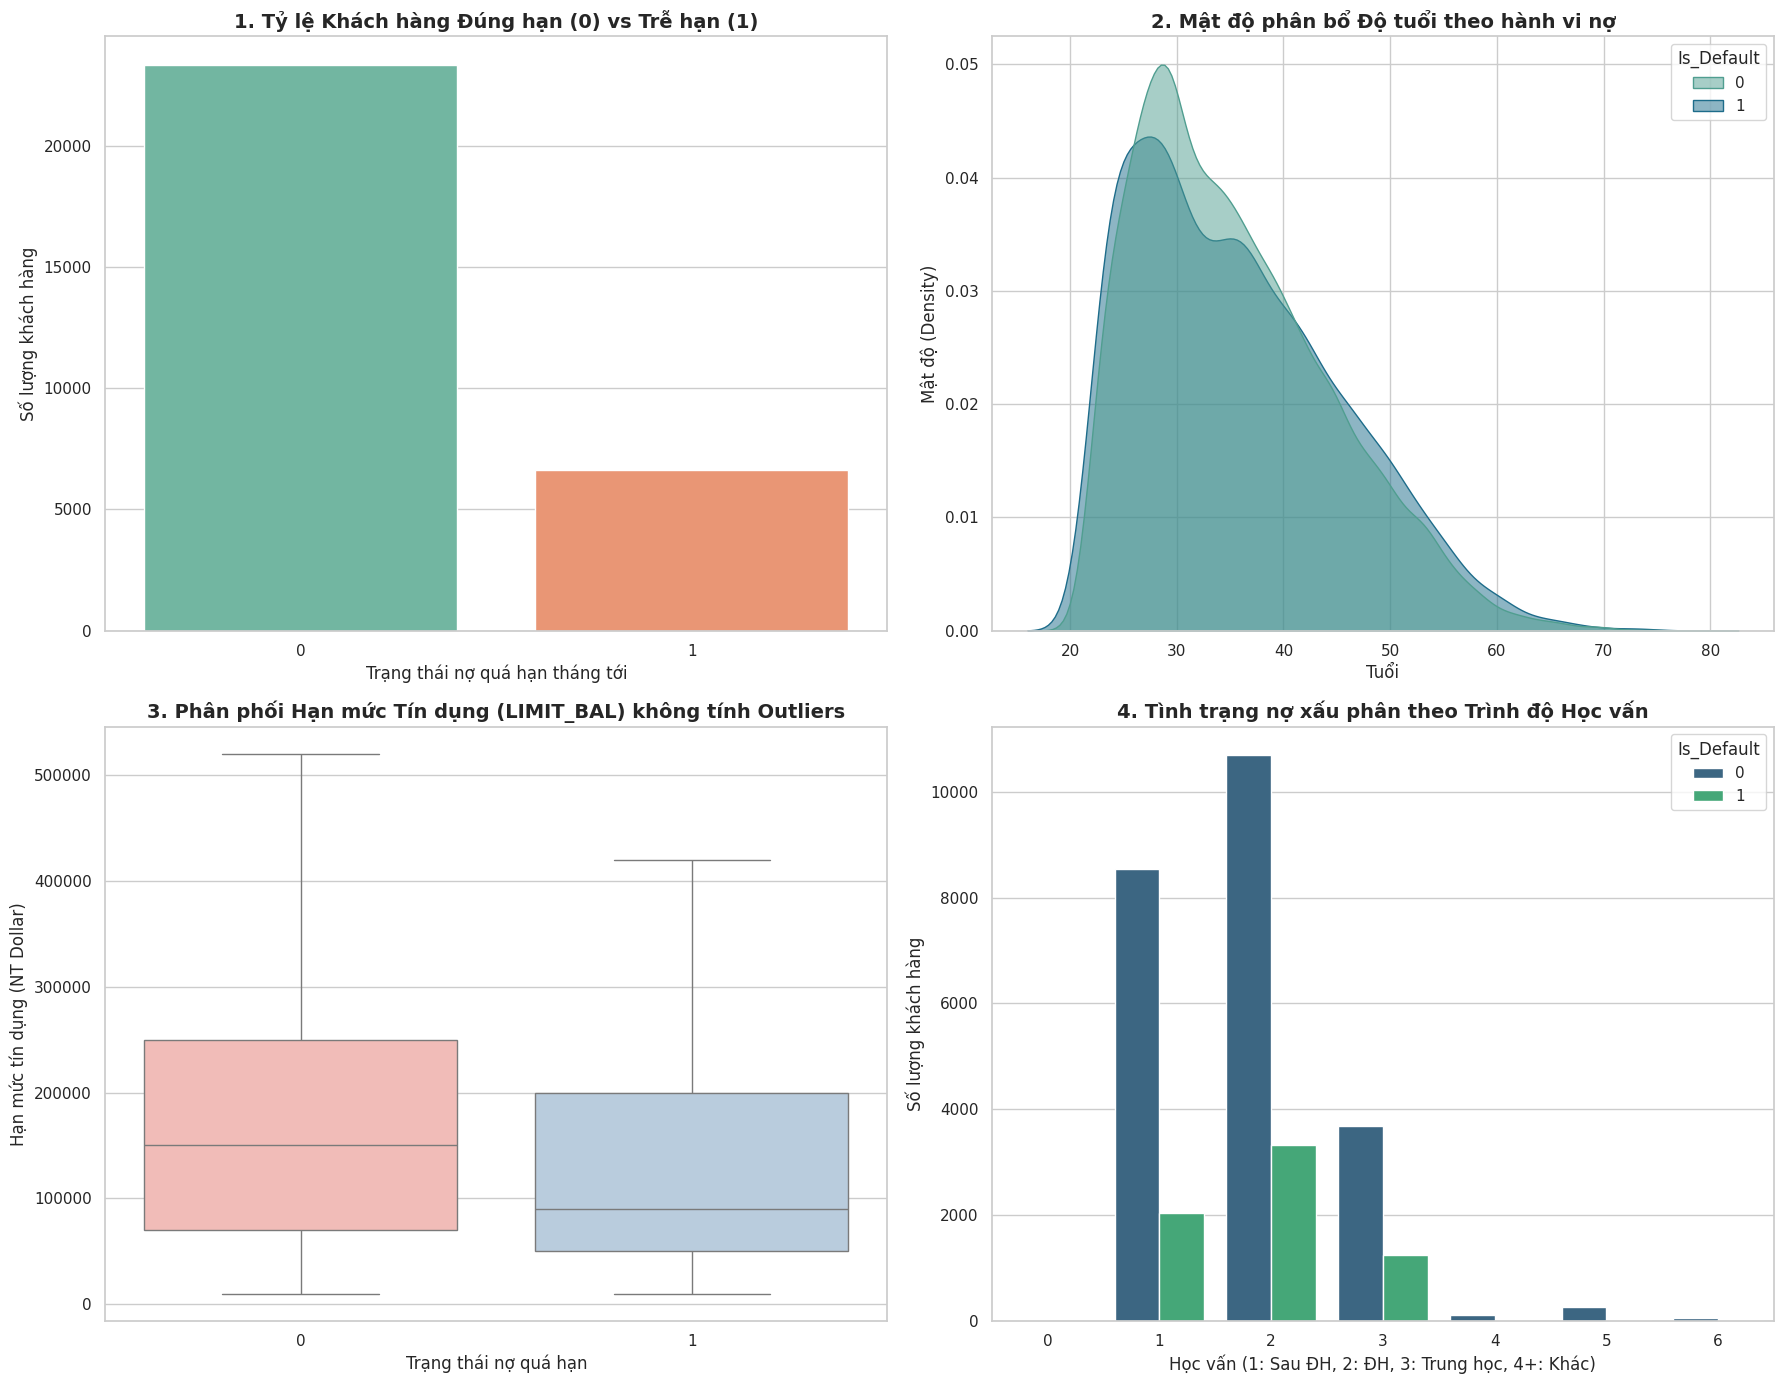

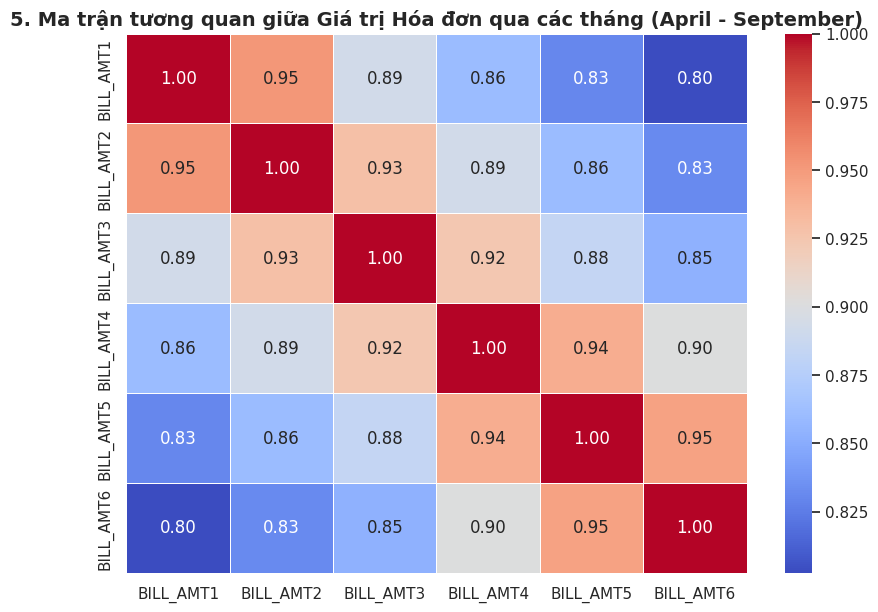

---------------------------------------------
Thống kê tỷ lệ phần trăm nợ xấu thực tế trong tập dữ liệu:
Is_Default
0    77.88
1    22.12
Name: proportion, dtype: float64


In [1]:
# ==============================================================================
# 1. KHAI BÁO CÁC THƯ VIỆN CẦN THIẾT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

# Thiết kế giao diện biểu đồ đẹp mắt hơn
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans' # Tránh lỗi font hiển thị trên Colab

# ==============================================================================
# 2. TẢI VÀ ĐỌC DỮ LIỆU TRỰC TIẾP TỪ UCI
# ==============================================================================
print("Đang tải dữ liệu từ UCI Machine Learning Repository... Vui lòng đợi trong giây lát.")
url = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"

response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    # Tìm file Excel bên trong file zip
    excel_file_name = [f for f in z.namelist() if f.endswith('.xls') or f.endswith('.xlsx')][0]
    with z.open(excel_file_name) as f:
        # Đọc file Excel, bỏ qua dòng tiêu đề phụ đầu tiên (header=1)
        df = pd.read_excel(f, header=1)

# Đổi tên cột biến mục tiêu cho gọn và chuẩn hóa ký tự đầu
df.rename(columns={'default payment next month': 'Is_Default'}, inplace=True)
print(f"Tải dữ liệu thành công! Kích thước tập dữ liệu: {df.shape}")
print("---" * 15)

# ==============================================================================
# 3. TRỰC QUAN HÓA DỮ LIỆU (DATA VISUALIZATION)
# ==============================================================================

# Tạo khung chứa 4 biểu đồ khác nhau để phân tích tổng quan
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Biểu đồ 1: Phân bổ biến mục tiêu (Target Variable Balance) ---
sns.countplot(ax=axes[0, 0], x='Is_Default', data=df, palette='Set2')
axes[0, 0].set_title('1. Tỷ lệ Khách hàng Đúng hạn (0) vs Trễ hạn (1)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Trạng thái nợ quá hạn tháng tới')
axes[0, 0].set_ylabel('Số lượng khách hàng')

# --- Biểu đồ 2: Phân bổ Độ tuổi theo trạng thái nợ (Age Distribution by Default) ---
sns.kdeplot(ax=axes[0, 1], x='AGE', hue='Is_Default', data=df, fill=True, common_norm=False, palette='crest', alpha=0.5)
axes[0, 1].set_title('2. Mật độ phân bổ Độ tuổi theo hành vi nợ', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tuổi')
axes[0, 1].set_ylabel('Mật độ (Density)')

# --- Biểu đồ 3: Hạn mức tín dụng tối đa (LIMIT_BAL) qua Boxplot ---
sns.boxplot(ax=axes[1, 0], x='Is_Default', y='LIMIT_BAL', data=df, palette='Pastel1', showfliers=False)
axes[1, 0].set_title('3. Phân phối Hạn mức Tín dụng (LIMIT_BAL) không tính Outliers', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Trạng thái nợ quá hạn')
axes[1, 0].set_ylabel('Hạn mức tín dụng (NT Dollar)')

# --- Biểu đồ 4: Mối quan hệ giữa Học vấn và Tỷ lệ nợ xấu ---
# 1=Sau đại học, 2=Đại học, 3=Trung học, 4=Khác
sns.countplot(ax=axes[1, 1], x='EDUCATION', hue='Is_Default', data=df, palette='viridis')
axes[1, 1].set_title('4. Tình trạng nợ xấu phân theo Trình độ Học vấn', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Học vấn (1: Sau ĐH, 2: ĐH, 3: Trung học, 4+: Khác)')
axes[1, 1].set_ylabel('Số lượng khách hàng')

plt.tight_layout()
plt.show()

# --- Biểu đồ 5: Ma trận tương quan giữa các hóa đơn (Phát hiện Đa cộng tuyến) ---
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
plt.figure(figsize=(10, 7))
corr_matrix = df[bill_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('5. Ma trận tương quan giữa Giá trị Hóa đơn qua các tháng (April - September)', fontsize=14, fontweight='bold')
plt.show()

# ==============================================================================
# 4. THỐNG KÊ MÔ TẢ NHANH (QUICK SUMMARY)
# ==============================================================================
print("---" * 15)
print("Thống kê tỷ lệ phần trăm nợ xấu thực tế trong tập dữ liệu:")
print(df['Is_Default'].value_counts(normalize=True) * 100)